<a href="https://colab.research.google.com/github/deorebhumika06/ai-projects/blob/main/Titanic%20Data%20Analysis%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Titanic Data Analysis Project



## 📌 Objective
To perform data cleaning, analysis, and visualization on the Titanic dataset and extract meaningful insights.
To analyze Titanic dataset and find patterns in survival based on different features.

## 🛠 Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

. Load Dataset

In [55]:
df=pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


 Data Understanding

In [56]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [47]:
df.isnull().sum()

AttributeError: 'NoneType' object has no attribute 'isnull'

In [46]:
df=df.dropna(subset=['Age'])
df=df.dropna()
df['Age']=df['Age'].fillna(0)

AttributeError: 'NoneType' object has no attribute 'dropna'

In [14]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [58]:
df=df.dropna(subset=['Cabin'])
df=df.dropna()
df['Cabin']=df['Cabin'].fillna(0)

In [57]:
df=df.dropna(subset=['Embarked'])
df=df.dropna()
df['Embarked']=df['Embarked'].fillna(0)

In [20]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,183,183,183,183,183
unique,183,2,127,133,3
top,"Cumings, Mrs. John Bradley (Florence Briggs Th...",male,19950,G6,S
freq,1,95,4,4,116


In [22]:
df.duplicated().sum()

np.int64(0)

In [ ]:
### 🔍 Data Understanding
Checking structure, data types, and missing values.

Data Cleaning

In [24]:
for col in df.describe(include='object').columns:
  print(col)
  print(df[col].nunique())
  print('_'*50)

Name
183
__________________________________________________
Sex
2
__________________________________________________
Ticket
127
__________________________________________________
Cabin
133
__________________________________________________
Embarked
3
__________________________________________________


In [26]:
for col in df.columns:
  if df[col].nunique():
    print(col)
    print(df[col].value_counts())
    print('_'*50)

PassengerId
PassengerId
2      1
4      1
7      1
11     1
12     1
      ..
872    1
873    1
880    1
888    1
890    1
Name: count, Length: 183, dtype: int64
__________________________________________________
Survived
Survived
1    123
0     60
Name: count, dtype: int64
__________________________________________________
Pclass
Pclass
1    158
2     15
3     10
Name: count, dtype: int64
__________________________________________________
Name
Name
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
McCarthy, Mr. Timothy J                                1
Sandstrom, Miss. Marguerite Rut                        1
Bonnell, Miss. Elizabeth                               1
                                                      ..
Beckwith, Mrs. Richard Leonard (Sallie Monypeny)       1
Carlsson, Mr. Frans Olof                               1
Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)          1
Graham, Miss. Margaret Edith     

In [53]:
df_sort=df.sort_values(by='Name').head(10)
df_sort

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
730,731,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
498,499,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S
460,461,1,1,"Anderson, Mr. Harry",male,48.00,0,0,19952,26.5500,E12,S
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.00,1,0,13502,77.9583,D7,S
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.00,0,0,112050,0.0000,A36,S
571,572,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.00,2,0,11769,51.4792,C101,S
700,701,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.00,1,0,PC 17757,227.5250,C62 C64,C
369,370,1,1,"Aubart, Mme. Leontine Pauline",female,24.00,0,0,PC 17477,69.3000,B35,C


In [56]:
df[['Name','Age']].value_counts()

,,count
Name,Age,
"Allen, Miss. Elisabeth Walton",29.00,1
"Allison, Master. Hudson Trevor",0.92,1
"Allison, Miss. Helen Loraine",2.00,1
"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.00,1
"Anderson, Mr. Harry",48.00,1
...,...,...
"White, Mr. Percival Wayland",54.00,1
"White, Mr. Richard Frasar",21.00,1
"Wick, Miss. Mary Natalie",31.00,1


In [60]:
df[['Name','Age']].sort_values(by=['Name','Age'])

,Name,Age
730,"Allen, Miss. Elisabeth Walton",29.00
305,"Allison, Master. Hudson Trevor",0.92
297,"Allison, Miss. Helen Loraine",2.00
498,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.00
460,"Anderson, Mr. Harry",48.00
...,...,...
124,"White, Mr. Percival Wayland",54.00
102,"White, Mr. Richard Frasar",21.00
318,"Wick, Miss. Mary Natalie",31.00
377,"Widener, Mr. Harry Elkins",27.00


In [3]:
import re

In [6]:
def extract_pclass(Pclass):
  pclass_no=re.findall('[0-9]+',str('pclass'))
  if len(pclass_no)>0:
    return int(pclass_no[0])
  else:
    return None
df['Pclass']=df['Pclass'].apply(extract_pclass)

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,None,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,None,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,None,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,None,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,None,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,None,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,None,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,None,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,None,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,None,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Visualization

Sex
male      577
female    314
Name: count, dtype: int64


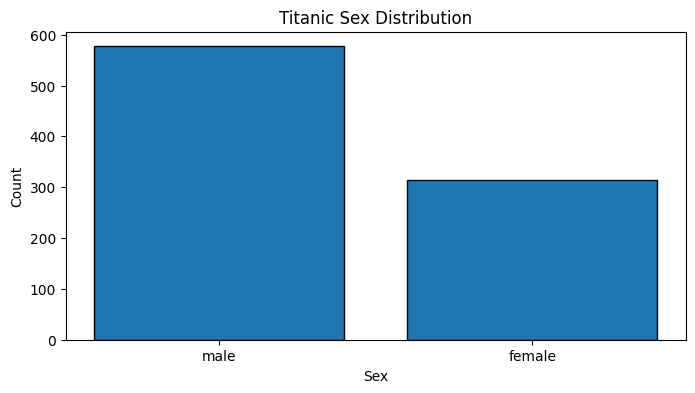

In [18]:
sex_val=df['Sex'].value_counts()
print(sex_val)
plt.figure(figsize=(8,4))
plt.bar(sex_val.index, sex_val.values, label='Sex', edgecolor="k")
plt.title('Titanic Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

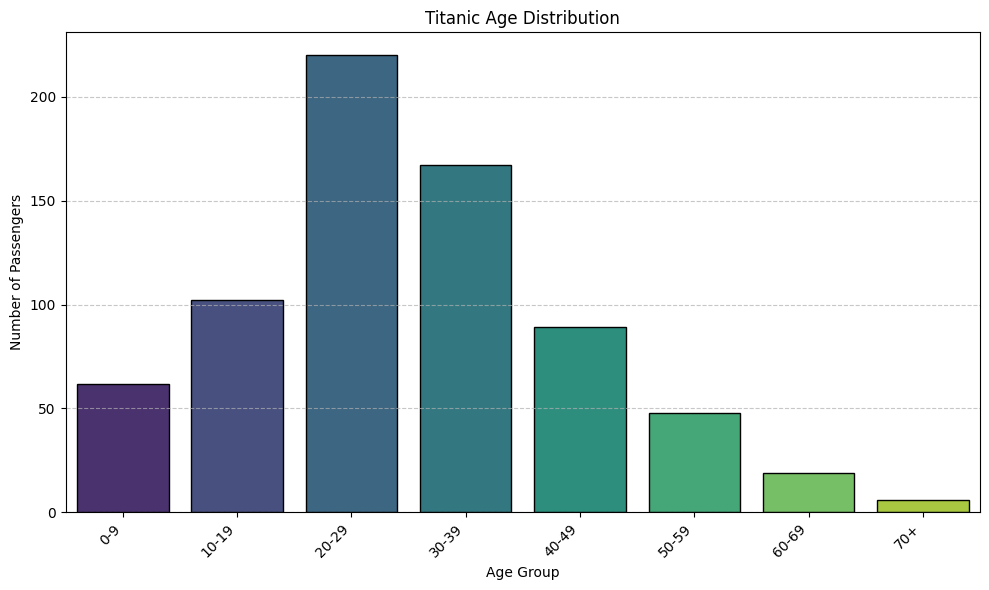

In [20]:

age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
age_group_counts = df['AgeGroup'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis', edgecolor='k')
plt.title('Titanic Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

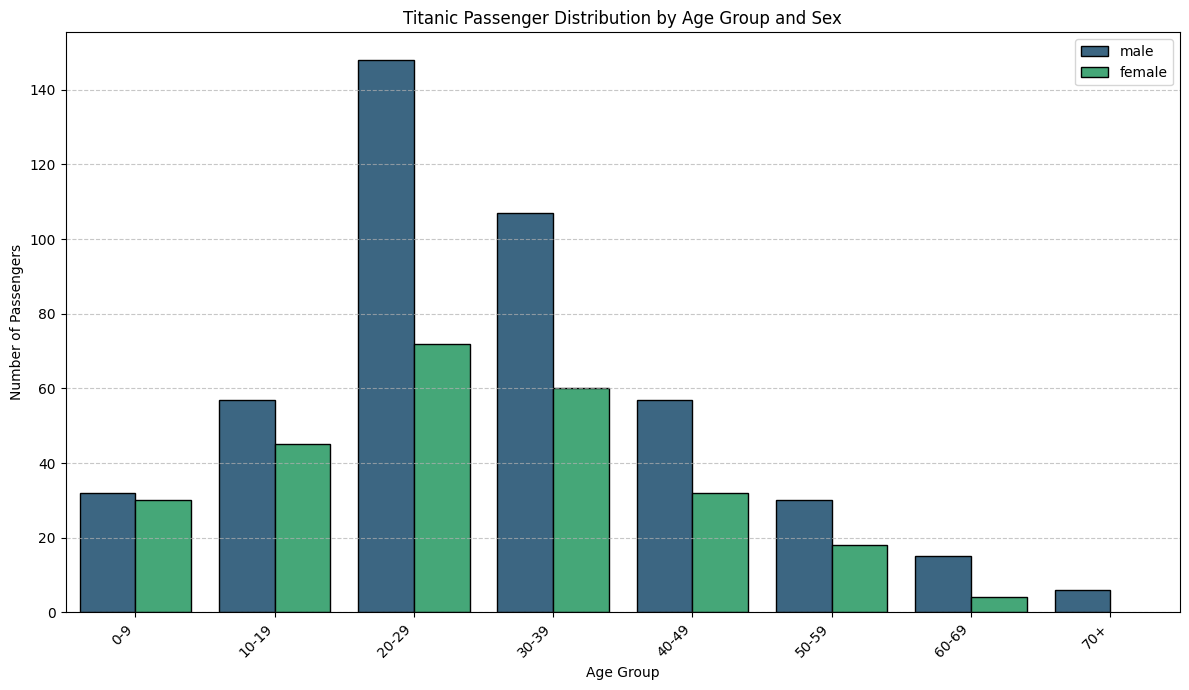

In [26]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='AgeGroup', hue='Sex', palette='viridis', edgecolor='k')
plt.legend(bbox_to_anchor=(1,1))
plt.title('Titanic Passenger Distribution by Age Group and Sex')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

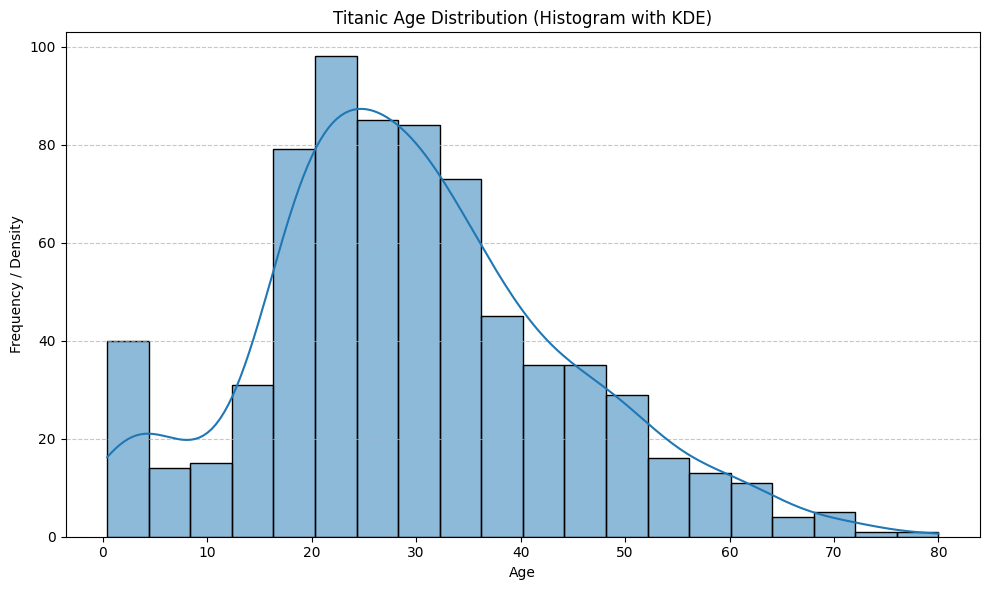

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=20, palette='viridis', edgecolor='k')
plt.title('Titanic Age Distribution (Histogram with KDE)')
plt.xlabel('Age')
plt.ylabel('Frequency / Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

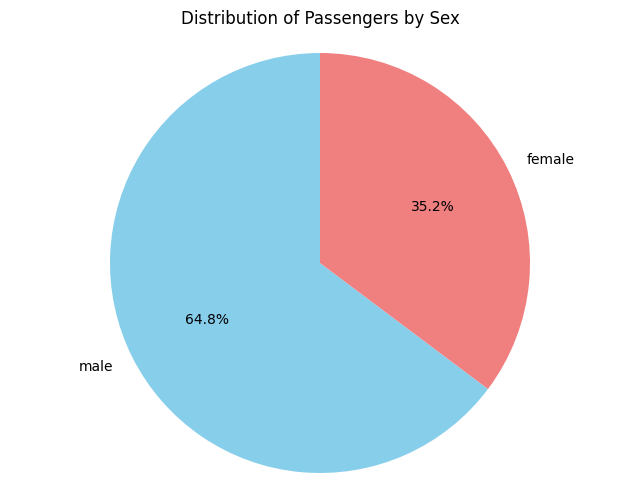

In [36]:
plt.figure(figsize=(8,6))
plt.pie(sex_val.values, labels=sex_val.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Passengers by Sex')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

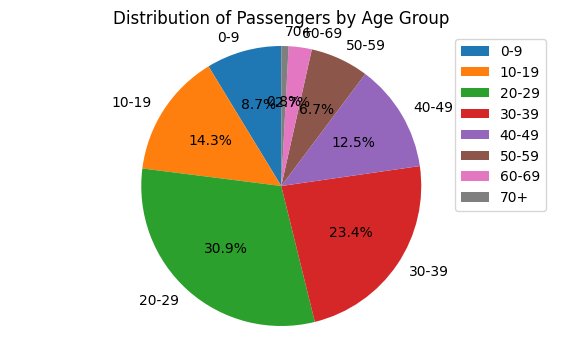

In [44]:
plt.figure(figsize=(7,4))
plt.pie(age_group_counts.values, labels=age_group_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Passengers by Age Group')
plt.legend(bbox_to_anchor=(1,1))
plt.axis('equal')
plt.show()

In [ ]:
#Data Visualization
Visualizing age distribution of passengers.

### Insight:
- Most passengers are between 20–30 age group
- Younger passengers are more frequent

## 🧠 Conclusion


- Female passengers had higher survival rate
- First class passengers survived more
- Age grouping helped understand distribution
- Most passengers were between age 20–30
- Females had higher survival rate
- First class passengers survived more
- Age grouping helped in better understanding distribution